# Classificatore basato su SVM Lineari ed N-grammi

In [2]:
! pip install loguru

In [ ]:
# Import dei moduli necessari
import utils_svm
import os
from loguru import logger

In [ ]:
# Caricamento dei dati
data_path = "data.json"
dataset = utils_svm.load_data(data_path)
conllu_dir = "Profiling_UD\\16152"

### Definizione delle classi

In [ ]:
# Classe per la gestione di ogni istanza all'interno del dataset
class Document: 

    def __init__(self, document_path, dataset):

        self.document_path = document_path
        self.doc_id = None
        self.split = None
        self.author = None
        self.text = None
        self._load_doc_info(document_path, dataset)
        self.sentences = []
        self.features = None

    # Funzione per l'individuazione delle istanze
    def _load_doc_info(self, document_path, dataset):
        self.doc_id = document_path.split('/')[-1].split('.')[0]
        self.split = dataset[self.doc_id]['split']
        self.author = dataset[self.doc_id]['author']
        self.text = dataset[self.doc_id]['text']

    # Funzione per l'aggiunta delle frasi all'elemento
    def add_sentence(self, sentence):
        self.sentences.append(sentence)
   
   # Funzione che ritorna il numero di tokens in una frase
    def get_num_tokens(self):
        num_words = 0
        for sentence in self.sentences:
            num_words = num_words + sentence.get_num_tokens()
        return num_words
    
    # Funzione che ritorna il numero di carattersi in una frase
    def get_num_chars(self):
        num_chars = 0
        for sentence in self.sentences:
            sentence_char_len = sentence.get_num_chars()
            num_chars = num_chars + sentence_char_len
        return num_chars
    
    # Funzione per stabilire come stampare ogni istanza della classe
    def __str__(self):
        return f"Document ID: {self.doc_id}, Author: {self.author}, Split: {self.split}"


In [ ]:
# Definizione della classe sentence per la gestione delle frasi
class Sentence:
    def __init__(self):
        self.tokens = []

    def add_token(self, token):
        self.tokens.append(token)

    def get_words(self):
        return [token.word for token in self.tokens]

    def get_lemmas(self):
        return [token.lemma for token in self.tokens]

    def get_pos(self):
        return [token.pos for token in self.tokens]

    def get_num_tokens(self):
        return len(self.tokens)
    
    # Funzione che ritorna il numero di caratteri in una frase
    def get_num_chars(self):
        num_chars = 0
        for token in self.tokens:
            num_chars = num_chars+token.get_num_chars()
        num_chars = num_chars+self.get_num_tokens() -1
        return num_chars
    
    def __str__(self):
        return ' '.join([token.word for token in self.tokens])

In [ ]:
# Classe per la gestione dei token
class Token:

    # Funzione per ottenere la parola e i corrispettivi lemma e pos
    def __init__(self, word, lemma, pos):
        self.word = word
        self.lemma = lemma
        self.pos = pos

    def get_num_chars(self):
        return len(self.word)

In [ ]:
# Funzione per il caricamento delle frasi all'interno di un documento

def load_document_sentences(document):
    """
    Funzione atta a caricare le frasi da un file `.conllu` associato a un documento
    e popolare l'oggetto `document` con frasi costituite da token.

    La funzione legge riga per riga il file, crea oggetti `Sentence` composti da
    istanze di `Token` (con lemma, forma e POS), e li aggiunge al documento.

    :args document: Document instance, oggetto che contiene il percorso al file 
                  e che verrà aggiornato con le frasi lette dal file.

    :returns none. Il documento viene aggiornato in-place.
    """

    sentence = Sentence()
    for line in open(document.document_path, 'r', encoding='UTF-8'):
            if line[0].isdigit():
                splitted_line = line.strip().split('\t')

                if '-' not in splitted_line[0]:
                    token = Token(splitted_line[1], splitted_line[2], splitted_line[3])
                    sentence.add_token(token)

            elif line =='\n':
                document.add_sentence(sentence)
                sentence =Sentence()

In [ ]:
# Inseriamo tutti i documenti in una lista
all_documents = []

# Ogni documento nella cartella è passato attraverso la classe document
for file_name in os.listdir(conllu_dir): 
    file_path = os.path.join(conllu_dir, file_name)
    document = Document(file_path, dataset)
    load_document_sentences(document)
    all_documents.append(document)

In [ ]:
# Controllo sulla tokenizzazione
sample_document = all_documents[657]
for sentence in sample_document.sentences[:5]:
    tokens = [token.word for token in sentence.tokens]
    print(' - '.join(tokens)+'\n')

When - Mr. - Wopsle - had - imparted - to - me - all - that - he - could - recall - or - I - extract - , - and - when - I - had - treated - him - to - a - little - appropriate - refreshment - , - after - the - fatigues - of - the - evening - , - we - parted - .

It - was - between - twelve - and - one - o’clock - when - I - reached - the - Temple - , - and - the - gates - were - shut - .

No - one - was - near - me - when - I - went - in - and - went - home - .



### Funzioni per il preprocessing

In [ ]:
def extract_word_ngrams_from_sentence(word_ngrams, sentence, el,  n):

    """
    Funzione che estrae n-grammi da una frase, in base al tipo di elemento linguistico selezionato (parola, lemma o POS), e aggiorna un dizionario con le occorrenze.

    :args word_ngrams: dizionario in cui vengono salvati gli n-grammi e le loro frequenze
    :args sentence: oggetto frase da cui estrarre gli n-grammi
    :args el: tipo di elemento da considerare ('word', 'lemma' o 'pos')
    :args n: lunghezza dell’n-gramma

    :returns word_ngrams: dizionario aggiornato con i nuovi n-grammi e frequenze
    """

    if el == 'word': 
        all_words = sentence.get_words()

    elif el == 'lemma':
        all_words = sentence.get_lemmas()
    
    elif el == 'pos':
        all_words = sentence.get_pos()

    else:
        raise Exception(f'Invalid element {el}')
    
    for i in range(0, len(all_words) - n+1):
        ngram_words = all_words[i: i+n]
        ngram = f'{el.upper()}_{n}_' + '_'.join(ngram_words)

        if ngram not in word_ngrams:
            word_ngrams[ngram] = 1

        else:
            word_ngrams[ngram] +=1

    return word_ngrams

In [ ]:
def extract_char_ngrams_from_sentence(char_ngrams, sentence, n):

    """
    Funzione che estrae n-grammi di caratteri da una frase, concatenando tutte le parole, e aggiorna un dizionario con le occorrenze trovate.

    :args char_ngrams: dizionario in cui vengono salvati gli n-grammi di caratteri e le loro frequenze
    :args sentence: oggetto frase da cui estrarre gli n-grammi di caratteri
    :args n: lunghezza dell’n-gramma di caratteri

    :returns char_ngrams: dizionario aggiornato con i nuovi n-grammi di caratteri e frequenze
    """

    all_words = sentence.get_words()

    all_words = ' '.join(all_words)

    for i in range(0, len(all_words) - n+1):
        ngram_chars = all_words[i:i+n]
        ngram = f'CHAR_{n}_'+ngram_chars

        if ngram not in char_ngrams:
            char_ngrams[ngram] = 1

        else:
            char_ngrams[ngram] += 1

    return char_ngrams

### Estrazione e normalizzazione delle features dai documenti

In [ ]:
# Funzione per la normalizzazione degli ngrammi sulla base della frequenza nel documento
def normalize_ngrams(ngrams_dict, doc_len):
    for ngram in ngrams_dict:
        ngrams_dict[ngram] = ngrams_dict[ngram]/float(doc_len)
        

In [ ]:
def extract_documents_ngrams_normalized(all_documents, element, num, id_funct):
    """
    Funzione che estrae n-grammi (di parole o caratteri) da tutti i documenti, normalizza le frequenze e aggiorna i documenti 
    con le nuove features.

    :args all_documents: lista di documenti, ciascuno contenente una lista di frasi
    :args element: tipo di elemento da usare per gli n-grammi di parola ('word', 'lemma', 'pos')
    :args num: lunghezza degli n-grammi
    :args id_funct: tipo di estrazione:
        0 - solo n-grammi di parole
        1 - solo n-grammi di caratteri
        2 - combinazione di entrambi con normalizzazione incrociata

    :returns None: la funzione aggiorna direttamente l’attributo `features` di ciascun documento
    """

    for document in all_documents:

        dic_name = {}
        words = {}
        chars = {}
        for sentence in document.sentences: 
            if id_funct == 0:
                extract_word_ngrams_from_sentence(dic_name, sentence, element, num)
                num_words = document.get_num_tokens()
                normalize_ngrams(dic_name, num_words)
                document_ngrams = dic_name
            elif id_funct == 1:
                extract_char_ngrams_from_sentence(dic_name, sentence, num)
                num_chars = document.get_num_chars()
                normalize_ngrams(dic_name, num_chars)
                document_ngrams = dic_name
            elif id_funct == 2:
                words = {}
                chars = {}
                extract_word_ngrams_from_sentence(words, sentence, element, num)
                extract_char_ngrams_from_sentence(chars, sentence, num)
                num_words = document.get_num_tokens()
                num_chars = document.get_num_chars()
                normalize_ngrams(words, num_chars)
                normalize_ngrams(chars, num_words)
                document_ngrams = words | chars
            else: 
                logger.error('L\'id della funzione non è corretto. Scegliere un numero da 0 a 2')

            document.features = document_ngrams

## Estrazione delle features

## Words

### Unigrammi di parole

In [65]:
extract_documents_ngrams_normalized(all_documents, element = 'word',  num = 1, id_funct = 0)
sample_document.features

{'WORD_1_When': 2.9154518950437314e-06,
 'WORD_1_Mr.': 2.9154518950437314e-06,
 'WORD_1_Wopsle': 2.9154518950437314e-06,
 'WORD_1_had': 5.830903790087463e-06,
 'WORD_1_imparted': 2.9154518950437314e-06,
 'WORD_1_to': 5.830903790087463e-06,
 'WORD_1_me': 0.014288629737609328,
 'WORD_1_all': 2.9154518950437314e-06,
 'WORD_1_that': 2.9154518950437314e-06,
 'WORD_1_he': 2.9154518950437314e-06,
 'WORD_1_could': 2.9154518950437314e-06,
 'WORD_1_recall': 2.9154518950437314e-06,
 'WORD_1_or': 2.9154518950437314e-06,
 'WORD_1_I': 0.014495626822157433,
 'WORD_1_extract': 2.9154518950437314e-06,
 'WORD_1_,': 0.00021282798833819244,
 'WORD_1_and': 0.014696793002915452,
 'WORD_1_when': 0.014492711370262392,
 'WORD_1_treated': 2.9154518950437314e-06,
 'WORD_1_him': 2.9154518950437314e-06,
 'WORD_1_a': 2.9154518950437314e-06,
 'WORD_1_little': 2.9154518950437314e-06,
 'WORD_1_appropriate': 2.9154518950437314e-06,
 'WORD_1_refreshment': 2.9154518950437314e-06,
 'WORD_1_after': 2.9154518950437314e-06,


Features pre cleaning:  3600
Numero features post filtro: 52
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.8622222222222223
Accuracy sul validation set: 0.7286666666666667
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.75      0.68      0.71       500
       Eliot       0.79      0.62      0.69       500
        Hugo       0.68      0.89      0.77       500

    accuracy                           0.73      1500
   macro avg       0.74      0.73      0.72      1500
weighted avg       0.74      0.73      0.72      1500



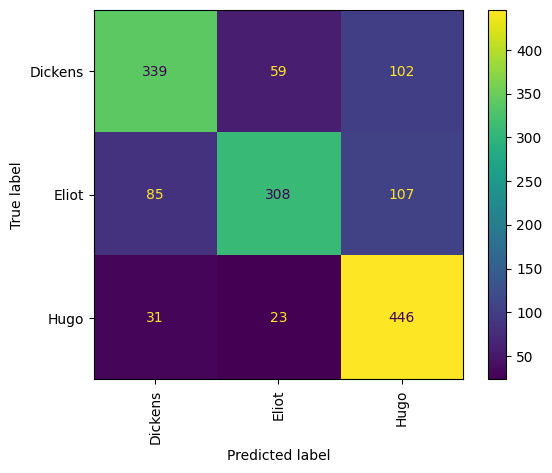

In [ ]:
x_test_unigrams, y_test_unigrams, unigram_model = utils_svm.training_val(all_documents, 5)

### Bigrammi di parole

In [67]:
extract_documents_ngrams_normalized(all_documents, element = 'word',  num = 2, id_funct = 0)
sample_document.features

{'WORD_2_When_Mr.': 2.9154518950437314e-06,
 'WORD_2_Mr._Wopsle': 2.9154518950437314e-06,
 'WORD_2_Wopsle_had': 2.9154518950437314e-06,
 'WORD_2_had_imparted': 2.9154518950437314e-06,
 'WORD_2_imparted_to': 2.9154518950437314e-06,
 'WORD_2_to_me': 2.9154518950437314e-06,
 'WORD_2_me_all': 2.9154518950437314e-06,
 'WORD_2_all_that': 2.9154518950437314e-06,
 'WORD_2_that_he': 2.9154518950437314e-06,
 'WORD_2_he_could': 2.9154518950437314e-06,
 'WORD_2_could_recall': 2.9154518950437314e-06,
 'WORD_2_recall_or': 2.9154518950437314e-06,
 'WORD_2_or_I': 2.9154518950437314e-06,
 'WORD_2_I_extract': 2.9154518950437314e-06,
 'WORD_2_extract_,': 2.9154518950437314e-06,
 'WORD_2_,_and': 0.00020699708454810492,
 'WORD_2_and_when': 2.9154518950437314e-06,
 'WORD_2_when_I': 0.014492711370262392,
 'WORD_2_I_had': 2.9154518950437314e-06,
 'WORD_2_had_treated': 2.9154518950437314e-06,
 'WORD_2_treated_him': 2.9154518950437314e-06,
 'WORD_2_him_to': 2.9154518950437314e-06,
 'WORD_2_to_a': 2.915451895043

Features pre cleaning:  3600
Numero features post filtro: 37
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.7941666666666667
Accuracy sul validation set: 0.7493333333333333
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.85      0.67      0.75       500
       Eliot       0.82      0.71      0.76       500
        Hugo       0.65      0.87      0.74       500

    accuracy                           0.75      1500
   macro avg       0.77      0.75      0.75      1500
weighted avg       0.77      0.75      0.75      1500



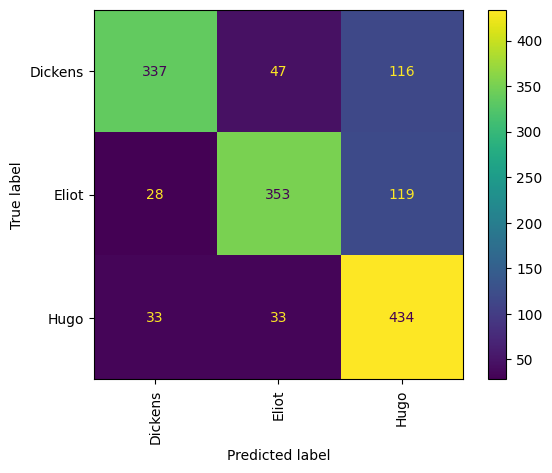

In [68]:
x_test_bigrams, y_test_bigrams, bigram_model = utils_svm.training_val(all_documents, 5)

### Trigrammi di parole

In [69]:
extract_documents_ngrams_normalized(all_documents, element = 'word',  num = 3, id_funct = 0)
sample_document.features

{'WORD_3_When_Mr._Wopsle': 2.9154518950437314e-06,
 'WORD_3_Mr._Wopsle_had': 2.9154518950437314e-06,
 'WORD_3_Wopsle_had_imparted': 2.9154518950437314e-06,
 'WORD_3_had_imparted_to': 2.9154518950437314e-06,
 'WORD_3_imparted_to_me': 2.9154518950437314e-06,
 'WORD_3_to_me_all': 2.9154518950437314e-06,
 'WORD_3_me_all_that': 2.9154518950437314e-06,
 'WORD_3_all_that_he': 2.9154518950437314e-06,
 'WORD_3_that_he_could': 2.9154518950437314e-06,
 'WORD_3_he_could_recall': 2.9154518950437314e-06,
 'WORD_3_could_recall_or': 2.9154518950437314e-06,
 'WORD_3_recall_or_I': 2.9154518950437314e-06,
 'WORD_3_or_I_extract': 2.9154518950437314e-06,
 'WORD_3_I_extract_,': 2.9154518950437314e-06,
 'WORD_3_extract_,_and': 2.9154518950437314e-06,
 'WORD_3_,_and_when': 2.9154518950437314e-06,
 'WORD_3_and_when_I': 2.9154518950437314e-06,
 'WORD_3_when_I_had': 2.9154518950437314e-06,
 'WORD_3_I_had_treated': 2.9154518950437314e-06,
 'WORD_3_had_treated_him': 2.9154518950437314e-06,
 'WORD_3_treated_him_to'

Features pre cleaning:  3600
Numero features post filtro: 299
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.7944444444444445
Accuracy sul validation set: 0.6906666666666667
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.72      0.64      0.68       500
       Eliot       0.70      0.64      0.67       500
        Hugo       0.66      0.79      0.72       500

    accuracy                           0.69      1500
   macro avg       0.69      0.69      0.69      1500
weighted avg       0.69      0.69      0.69      1500



C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


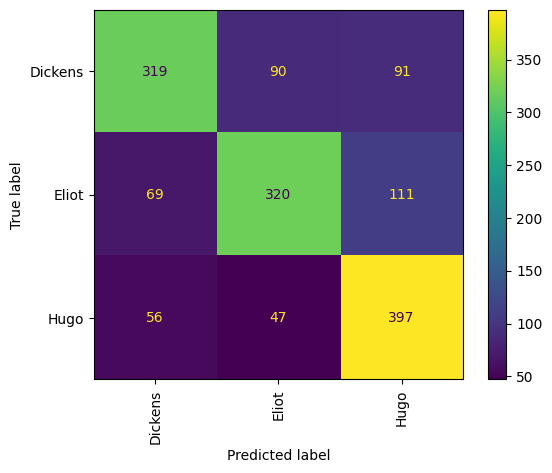

In [105]:
x_test_trigrams, y_test_trigrams, trigram_model = utils_svm.training_val(all_documents, 5)

### 4-Ngrammi di parole 

In [ ]:
extract_documents_ngrams_normalized(all_documents, element = 'word',  num = 4, id_funct = 0)
sample_document.features

Features pre cleaning:  3600
Numero features post filtro: 0
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.45111111111111113
Accuracy sul validation set: 0.398
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.53      0.11      0.18       500
       Eliot       0.66      0.12      0.21       500
        Hugo       0.37      0.96      0.53       500

    accuracy                           0.40      1500
   macro avg       0.52      0.40      0.31      1500
weighted avg       0.52      0.40      0.31      1500



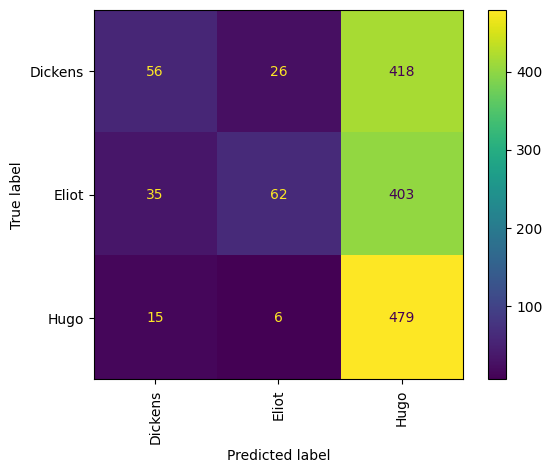

In [72]:
x_test_unigrams, y_test_unigrams, four_gram_model = utils_svm.training_val(all_documents, 5)

### 5-Ngrammi di parole

In [73]:
extract_documents_ngrams_normalized(all_documents, element = 'word',  num = 5, id_funct = 0)
#sample_document.features

Features pre cleaning:  3600
Numero features post filtro: 0
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.40388888888888885
Accuracy sul validation set: 0.35333333333333333
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.44      0.01      0.02       500
       Eliot       0.93      0.05      0.10       500
        Hugo       0.34      1.00      0.51       500

    accuracy                           0.35      1500
   macro avg       0.57      0.35      0.21      1500
weighted avg       0.57      0.35      0.21      1500



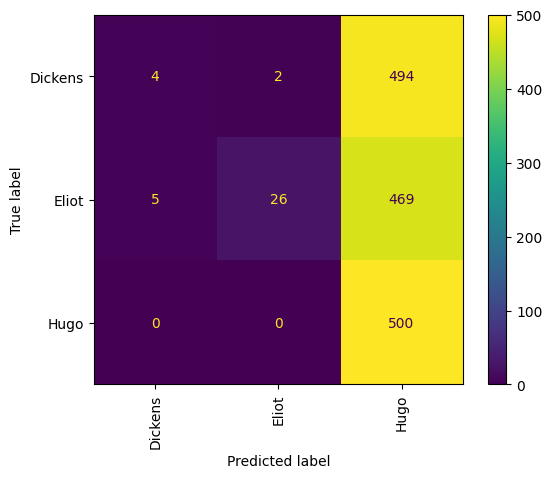

In [74]:
x_test_unigrams, y_test_unigrams, five_gram_model = utils_svm.training_val(all_documents, 5)

## Lemmas

#### Unigrammi di lemmi

In [75]:
extract_documents_ngrams_normalized(all_documents, element = 'lemma',  num = 1, id_funct = 0)
sample_document.features

{'LEMMA_1_when': 0.014495626822157433,
 'LEMMA_1_Mr.': 2.9154518950437314e-06,
 'LEMMA_1_Wopsle': 2.9154518950437314e-06,
 'LEMMA_1_have': 5.830903790087463e-06,
 'LEMMA_1_impart': 2.9154518950437314e-06,
 'LEMMA_1_to': 5.830903790087463e-06,
 'LEMMA_1_I': 0.028784256559766762,
 'LEMMA_1_all': 2.9154518950437314e-06,
 'LEMMA_1_that': 2.9154518950437314e-06,
 'LEMMA_1_he': 5.830903790087463e-06,
 'LEMMA_1_could': 2.9154518950437314e-06,
 'LEMMA_1_recall': 2.9154518950437314e-06,
 'LEMMA_1_or': 2.9154518950437314e-06,
 'LEMMA_1_extract': 2.9154518950437314e-06,
 'LEMMA_1_,': 0.00021282798833819244,
 'LEMMA_1_and': 0.014696793002915452,
 'LEMMA_1_treat': 2.9154518950437314e-06,
 'LEMMA_1_a': 2.9154518950437314e-06,
 'LEMMA_1_little': 2.9154518950437314e-06,
 'LEMMA_1_appropriate': 2.9154518950437314e-06,
 'LEMMA_1_refreshment': 2.9154518950437314e-06,
 'LEMMA_1_after': 2.9154518950437314e-06,
 'LEMMA_1_the': 0.00041399416909620985,
 'LEMMA_1_fatigue': 2.9154518950437314e-06,
 'LEMMA_1_of'

Features pre cleaning:  3600
Numero features post filtro: 48
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.8541666666666666
Accuracy sul validation set: 0.716
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.80      0.72      0.75       500
       Eliot       0.71      0.64      0.67       500
        Hugo       0.66      0.79      0.72       500

    accuracy                           0.72      1500
   macro avg       0.72      0.72      0.72      1500
weighted avg       0.72      0.72      0.72      1500



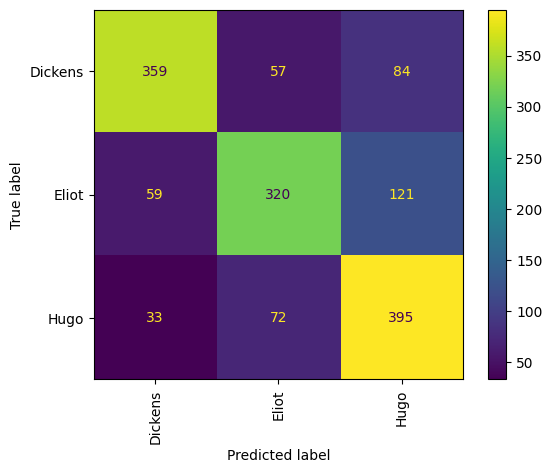

In [76]:
x_test_uni_lemmas, y_test_uni_lemmas, uni_lemmas_model = utils_svm.training_val(all_documents, 5)

#### Bigrammi di Lemmi

In [77]:
extract_documents_ngrams_normalized(all_documents, element = 'lemma',  num = 2, id_funct = 0)
sample_document.features

{'LEMMA_2_when_Mr.': 2.9154518950437314e-06,
 'LEMMA_2_Mr._Wopsle': 2.9154518950437314e-06,
 'LEMMA_2_Wopsle_have': 2.9154518950437314e-06,
 'LEMMA_2_have_impart': 2.9154518950437314e-06,
 'LEMMA_2_impart_to': 2.9154518950437314e-06,
 'LEMMA_2_to_I': 2.9154518950437314e-06,
 'LEMMA_2_I_all': 2.9154518950437314e-06,
 'LEMMA_2_all_that': 2.9154518950437314e-06,
 'LEMMA_2_that_he': 2.9154518950437314e-06,
 'LEMMA_2_he_could': 2.9154518950437314e-06,
 'LEMMA_2_could_recall': 2.9154518950437314e-06,
 'LEMMA_2_recall_or': 2.9154518950437314e-06,
 'LEMMA_2_or_I': 2.9154518950437314e-06,
 'LEMMA_2_I_extract': 2.9154518950437314e-06,
 'LEMMA_2_extract_,': 2.9154518950437314e-06,
 'LEMMA_2_,_and': 0.00020699708454810492,
 'LEMMA_2_and_when': 2.9154518950437314e-06,
 'LEMMA_2_when_I': 0.014492711370262392,
 'LEMMA_2_I_have': 2.9154518950437314e-06,
 'LEMMA_2_have_treat': 2.9154518950437314e-06,
 'LEMMA_2_treat_he': 2.9154518950437314e-06,
 'LEMMA_2_he_to': 2.9154518950437314e-06,
 'LEMMA_2_to_a':

Features pre cleaning:  3600
Numero features post filtro: 41
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.7955555555555556
Accuracy sul validation set: 0.734
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.85      0.69      0.76       500
       Eliot       0.78      0.67      0.72       500
        Hugo       0.63      0.85      0.72       500

    accuracy                           0.73      1500
   macro avg       0.76      0.73      0.74      1500
weighted avg       0.76      0.73      0.74      1500



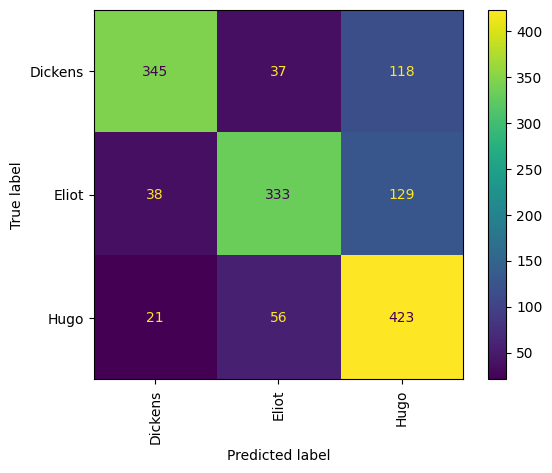

In [78]:
x_test_bi_lemmas, y_test_bi_lemmas, bi_lemmas_model = utils_svm.training_val(all_documents, 5)

#### Trigrammi di Lemmi

In [79]:
extract_documents_ngrams_normalized(all_documents, element = 'lemma',  num = 3, id_funct = 0)
sample_document.features

{'LEMMA_3_when_Mr._Wopsle': 2.9154518950437314e-06,
 'LEMMA_3_Mr._Wopsle_have': 2.9154518950437314e-06,
 'LEMMA_3_Wopsle_have_impart': 2.9154518950437314e-06,
 'LEMMA_3_have_impart_to': 2.9154518950437314e-06,
 'LEMMA_3_impart_to_I': 2.9154518950437314e-06,
 'LEMMA_3_to_I_all': 2.9154518950437314e-06,
 'LEMMA_3_I_all_that': 2.9154518950437314e-06,
 'LEMMA_3_all_that_he': 2.9154518950437314e-06,
 'LEMMA_3_that_he_could': 2.9154518950437314e-06,
 'LEMMA_3_he_could_recall': 2.9154518950437314e-06,
 'LEMMA_3_could_recall_or': 2.9154518950437314e-06,
 'LEMMA_3_recall_or_I': 2.9154518950437314e-06,
 'LEMMA_3_or_I_extract': 2.9154518950437314e-06,
 'LEMMA_3_I_extract_,': 2.9154518950437314e-06,
 'LEMMA_3_extract_,_and': 2.9154518950437314e-06,
 'LEMMA_3_,_and_when': 2.9154518950437314e-06,
 'LEMMA_3_and_when_I': 2.9154518950437314e-06,
 'LEMMA_3_when_I_have': 2.9154518950437314e-06,
 'LEMMA_3_I_have_treat': 2.9154518950437314e-06,
 'LEMMA_3_have_treat_he': 2.9154518950437314e-06,
 'LEMMA_3_tr

Features pre cleaning:  3600
Numero features post filtro: 16
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.5730555555555555
Accuracy sul validation set: 0.5246666666666666
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.54      0.34      0.41       500
       Eliot       0.60      0.47      0.52       500
        Hugo       0.48      0.77      0.59       500

    accuracy                           0.52      1500
   macro avg       0.54      0.52      0.51      1500
weighted avg       0.54      0.52      0.51      1500



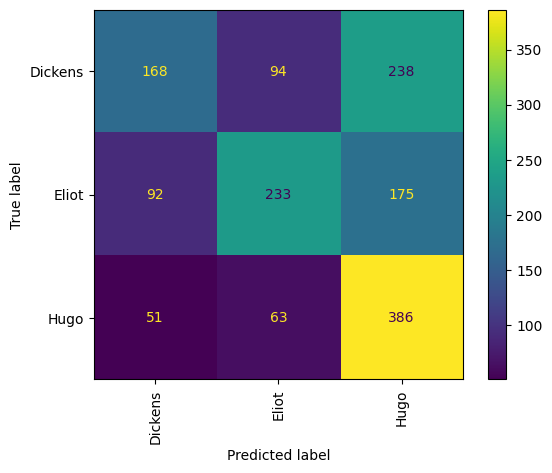

In [80]:
x_test_tri_lemmas, y_test_tri_lemmas, tri_lemmas_model = utils_svm.training_val(all_documents, 5)

#### 4-ngrams di Lemmi

In [81]:
extract_documents_ngrams_normalized(all_documents, element = 'lemma',  num = 4, id_funct = 0)
sample_document.features

{'LEMMA_4_when_Mr._Wopsle_have': 2.9154518950437314e-06,
 'LEMMA_4_Mr._Wopsle_have_impart': 2.9154518950437314e-06,
 'LEMMA_4_Wopsle_have_impart_to': 2.9154518950437314e-06,
 'LEMMA_4_have_impart_to_I': 2.9154518950437314e-06,
 'LEMMA_4_impart_to_I_all': 2.9154518950437314e-06,
 'LEMMA_4_to_I_all_that': 2.9154518950437314e-06,
 'LEMMA_4_I_all_that_he': 2.9154518950437314e-06,
 'LEMMA_4_all_that_he_could': 2.9154518950437314e-06,
 'LEMMA_4_that_he_could_recall': 2.9154518950437314e-06,
 'LEMMA_4_he_could_recall_or': 2.9154518950437314e-06,
 'LEMMA_4_could_recall_or_I': 2.9154518950437314e-06,
 'LEMMA_4_recall_or_I_extract': 2.9154518950437314e-06,
 'LEMMA_4_or_I_extract_,': 2.9154518950437314e-06,
 'LEMMA_4_I_extract_,_and': 2.9154518950437314e-06,
 'LEMMA_4_extract_,_and_when': 2.9154518950437314e-06,
 'LEMMA_4_,_and_when_I': 2.9154518950437314e-06,
 'LEMMA_4_and_when_I_have': 2.9154518950437314e-06,
 'LEMMA_4_when_I_have_treat': 2.9154518950437314e-06,
 'LEMMA_4_I_have_treat_he': 2.91

Features pre cleaning:  3600
Numero features post filtro: 1
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.45
Accuracy sul validation set: 0.41333333333333333
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.44      0.14      0.21       500
       Eliot       0.65      0.18      0.28       500
        Hugo       0.38      0.92      0.54       500

    accuracy                           0.41      1500
   macro avg       0.49      0.41      0.34      1500
weighted avg       0.49      0.41      0.34      1500



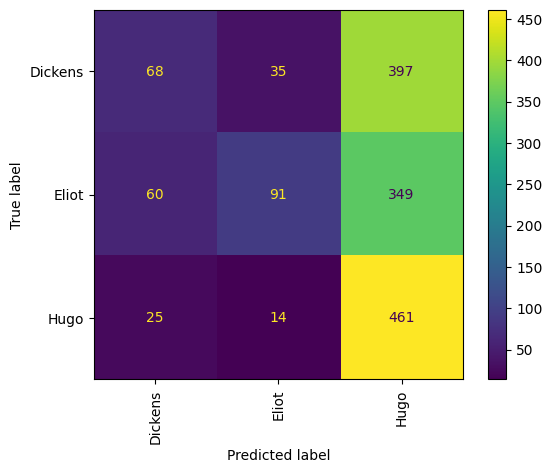

In [82]:
x_test_four_lemmas, y_test_four_lemmas, four_lemmas_model = utils_svm.training_val(all_documents, 5)

#### 5-ngrams di Lemmi

In [83]:
extract_documents_ngrams_normalized(all_documents, element = 'lemma',  num = 5, id_funct = 0)
sample_document.features

{'LEMMA_5_when_Mr._Wopsle_have_impart': 2.9154518950437314e-06,
 'LEMMA_5_Mr._Wopsle_have_impart_to': 2.9154518950437314e-06,
 'LEMMA_5_Wopsle_have_impart_to_I': 2.9154518950437314e-06,
 'LEMMA_5_have_impart_to_I_all': 2.9154518950437314e-06,
 'LEMMA_5_impart_to_I_all_that': 2.9154518950437314e-06,
 'LEMMA_5_to_I_all_that_he': 2.9154518950437314e-06,
 'LEMMA_5_I_all_that_he_could': 2.9154518950437314e-06,
 'LEMMA_5_all_that_he_could_recall': 2.9154518950437314e-06,
 'LEMMA_5_that_he_could_recall_or': 2.9154518950437314e-06,
 'LEMMA_5_he_could_recall_or_I': 2.9154518950437314e-06,
 'LEMMA_5_could_recall_or_I_extract': 2.9154518950437314e-06,
 'LEMMA_5_recall_or_I_extract_,': 2.9154518950437314e-06,
 'LEMMA_5_or_I_extract_,_and': 2.9154518950437314e-06,
 'LEMMA_5_I_extract_,_and_when': 2.9154518950437314e-06,
 'LEMMA_5_extract_,_and_when_I': 2.9154518950437314e-06,
 'LEMMA_5_,_and_when_I_have': 2.9154518950437314e-06,
 'LEMMA_5_and_when_I_have_treat': 2.9154518950437314e-06,
 'LEMMA_5_wh

Features pre cleaning:  3600
Numero features post filtro: 0
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.3883333333333333
Accuracy sul validation set: 0.35733333333333334
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.67      0.02      0.04       500
       Eliot       0.85      0.06      0.11       500
        Hugo       0.34      0.99      0.51       500

    accuracy                           0.36      1500
   macro avg       0.62      0.36      0.22      1500
weighted avg       0.62      0.36      0.22      1500



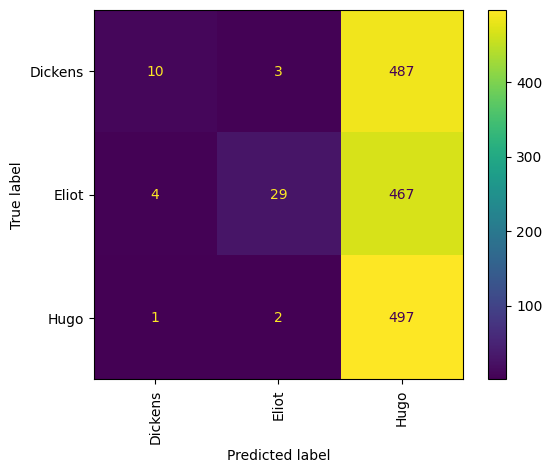

In [84]:
x_test_five_lemmas, y_test_five_lemmas, five_lemmas_model = utils_svm.training_val(all_documents, 5)

## POS

#### Unigrammi di POS

In [85]:
extract_documents_ngrams_normalized(all_documents, element = 'pos',  num = 1, id_funct = 0)
sample_document.features

{'POS_1_ADV': 0.04306705539358601,
 'POS_1_PROPN': 5.830903790087463e-06,
 'POS_1_AUX': 0.01470262390670554,
 'POS_1_VERB': 0.02879008746355685,
 'POS_1_ADP': 0.014501457725947521,
 'POS_1_PRON': 0.028997084548104953,
 'POS_1_DET': 0.014705539358600582,
 'POS_1_SCONJ': 2.9154518950437314e-06,
 'POS_1_CCONJ': 0.014699708454810494,
 'POS_1_PUNCT': 0.014705539358600582,
 'POS_1_ADJ': 0.00020991253644314867,
 'POS_1_NOUN': 0.0149067055393586,
 'POS_1_NUM': 0.0004081632653061224}

Features pre cleaning:  3600
Numero features post filtro: 14
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.5283333333333333
Accuracy sul validation set: 0.49533333333333335
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.48      0.46      0.47       500
       Eliot       0.40      0.36      0.38       500
        Hugo       0.58      0.67      0.62       500

    accuracy                           0.50      1500
   macro avg       0.49      0.50      0.49      1500
weighted avg       0.49      0.50      0.49      1500



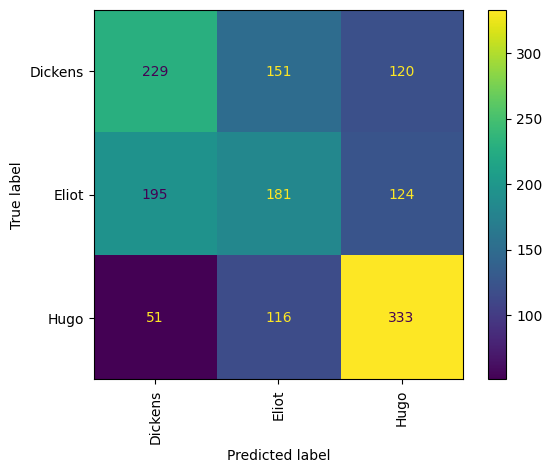

In [86]:
x_test_uni_POS, y_test_uni_POS, uni_POS_model = utils_svm.training_val(all_documents, 5)

#### Bigrammi di POS

In [87]:
extract_documents_ngrams_normalized(all_documents, element = 'pos',  num = 2, id_funct = 0)
sample_document.features

{'POS_2_ADV_PROPN': 2.9154518950437314e-06,
 'POS_2_PROPN_PROPN': 2.9154518950437314e-06,
 'POS_2_PROPN_AUX': 2.9154518950437314e-06,
 'POS_2_AUX_VERB': 8.746355685131195e-06,
 'POS_2_VERB_ADP': 2.9154518950437314e-06,
 'POS_2_ADP_PRON': 0.014288629737609328,
 'POS_2_PRON_DET': 2.9154518950437314e-06,
 'POS_2_DET_SCONJ': 2.9154518950437314e-06,
 'POS_2_SCONJ_PRON': 2.9154518950437314e-06,
 'POS_2_PRON_AUX': 0.00020991253644314867,
 'POS_2_VERB_CCONJ': 2.9154518950437314e-06,
 'POS_2_CCONJ_PRON': 2.9154518950437314e-06,
 'POS_2_PRON_VERB': 0.014495626822157433,
 'POS_2_VERB_PUNCT': 5.830903790087463e-06,
 'POS_2_PUNCT_CCONJ': 0.00020699708454810492,
 'POS_2_CCONJ_ADV': 2.9154518950437314e-06,
 'POS_2_ADV_PRON': 0.014492711370262392,
 'POS_2_VERB_PRON': 2.9154518950437314e-06,
 'POS_2_PRON_ADP': 2.9154518950437314e-06,
 'POS_2_ADP_DET': 8.746355685131195e-06,
 'POS_2_DET_ADJ': 2.9154518950437314e-06,
 'POS_2_ADJ_ADJ': 2.9154518950437314e-06,
 'POS_2_ADJ_NOUN': 2.9154518950437314e-06,
 'P

Features pre cleaning:  3600
Numero features post filtro: 42
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.6047222222222223


C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy sul validation set: 0.5766666666666667
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.51      0.49      0.50       500
       Eliot       0.53      0.51      0.52       500
        Hugo       0.67      0.74      0.70       500

    accuracy                           0.58      1500
   macro avg       0.57      0.58      0.57      1500
weighted avg       0.57      0.58      0.57      1500



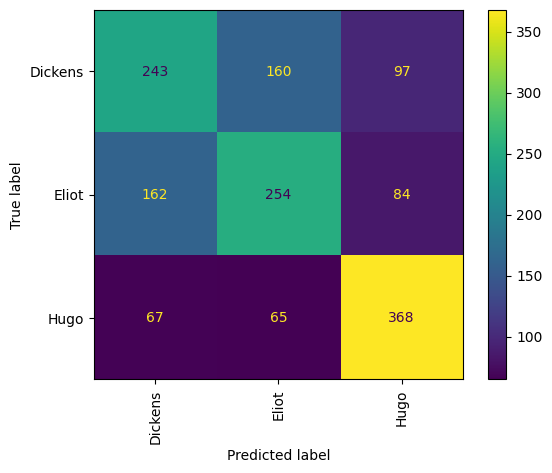

In [88]:
x_test_bi_POS, y_test_bi_POS, bi_POS_model = utils_svm.training_val(all_documents, 5)

#### Trigrammi di POS

In [89]:
extract_documents_ngrams_normalized(all_documents, element = 'pos',  num = 3, id_funct = 0)
sample_document.features

{'POS_3_ADV_PROPN_PROPN': 2.9154518950437314e-06,
 'POS_3_PROPN_PROPN_AUX': 2.9154518950437314e-06,
 'POS_3_PROPN_AUX_VERB': 2.9154518950437314e-06,
 'POS_3_AUX_VERB_ADP': 2.9154518950437314e-06,
 'POS_3_VERB_ADP_PRON': 2.9154518950437314e-06,
 'POS_3_ADP_PRON_DET': 2.9154518950437314e-06,
 'POS_3_PRON_DET_SCONJ': 2.9154518950437314e-06,
 'POS_3_DET_SCONJ_PRON': 2.9154518950437314e-06,
 'POS_3_SCONJ_PRON_AUX': 2.9154518950437314e-06,
 'POS_3_PRON_AUX_VERB': 5.830903790087463e-06,
 'POS_3_AUX_VERB_CCONJ': 2.9154518950437314e-06,
 'POS_3_VERB_CCONJ_PRON': 2.9154518950437314e-06,
 'POS_3_CCONJ_PRON_VERB': 2.9154518950437314e-06,
 'POS_3_PRON_VERB_PUNCT': 5.830903790087463e-06,
 'POS_3_VERB_PUNCT_CCONJ': 2.9154518950437314e-06,
 'POS_3_PUNCT_CCONJ_ADV': 2.9154518950437314e-06,
 'POS_3_CCONJ_ADV_PRON': 2.9154518950437314e-06,
 'POS_3_ADV_PRON_AUX': 2.9154518950437314e-06,
 'POS_3_AUX_VERB_PRON': 2.9154518950437314e-06,
 'POS_3_VERB_PRON_ADP': 2.9154518950437314e-06,
 'POS_3_PRON_ADP_DET': 2

Features pre cleaning:  3600
Numero features post filtro: 64
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.5533333333333333
Accuracy sul validation set: 0.546
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.48      0.44      0.46       500
       Eliot       0.49      0.49      0.49       500
        Hugo       0.66      0.71      0.68       500

    accuracy                           0.55      1500
   macro avg       0.54      0.55      0.54      1500
weighted avg       0.54      0.55      0.54      1500



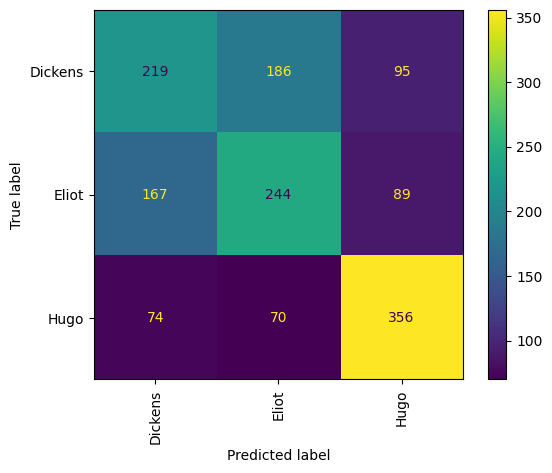

In [90]:
x_test_tri_POS, y_test_tri_POS, tri_POS_model = utils_svm.training_val(all_documents, 5)

#### 4-grammi di POS

In [91]:
extract_documents_ngrams_normalized(all_documents, element = 'pos',  num = 4, id_funct = 0)
sample_document.features

{'POS_4_ADV_PROPN_PROPN_AUX': 2.9154518950437314e-06,
 'POS_4_PROPN_PROPN_AUX_VERB': 2.9154518950437314e-06,
 'POS_4_PROPN_AUX_VERB_ADP': 2.9154518950437314e-06,
 'POS_4_AUX_VERB_ADP_PRON': 2.9154518950437314e-06,
 'POS_4_VERB_ADP_PRON_DET': 2.9154518950437314e-06,
 'POS_4_ADP_PRON_DET_SCONJ': 2.9154518950437314e-06,
 'POS_4_PRON_DET_SCONJ_PRON': 2.9154518950437314e-06,
 'POS_4_DET_SCONJ_PRON_AUX': 2.9154518950437314e-06,
 'POS_4_SCONJ_PRON_AUX_VERB': 2.9154518950437314e-06,
 'POS_4_PRON_AUX_VERB_CCONJ': 2.9154518950437314e-06,
 'POS_4_AUX_VERB_CCONJ_PRON': 2.9154518950437314e-06,
 'POS_4_VERB_CCONJ_PRON_VERB': 2.9154518950437314e-06,
 'POS_4_CCONJ_PRON_VERB_PUNCT': 2.9154518950437314e-06,
 'POS_4_PRON_VERB_PUNCT_CCONJ': 2.9154518950437314e-06,
 'POS_4_VERB_PUNCT_CCONJ_ADV': 2.9154518950437314e-06,
 'POS_4_PUNCT_CCONJ_ADV_PRON': 2.9154518950437314e-06,
 'POS_4_CCONJ_ADV_PRON_AUX': 2.9154518950437314e-06,
 'POS_4_ADV_PRON_AUX_VERB': 2.9154518950437314e-06,
 'POS_4_PRON_AUX_VERB_PRON': 2

Features pre cleaning:  3600
Numero features post filtro: 69
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.5222222222222224
Accuracy sul validation set: 0.5226666666666666
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.47      0.43      0.45       500
       Eliot       0.49      0.46      0.47       500
        Hugo       0.60      0.68      0.63       500

    accuracy                           0.52      1500
   macro avg       0.52      0.52      0.52      1500
weighted avg       0.52      0.52      0.52      1500



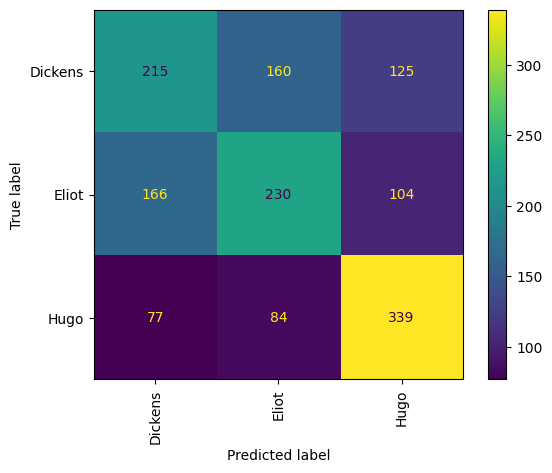

In [92]:
x_test_four_POS, y_test_four_POS, four_POS_model = utils_svm.training_val(all_documents, 5)

#### 5-grammi POS

In [93]:
extract_documents_ngrams_normalized(all_documents, element = 'pos',  num = 5, id_funct = 0)
sample_document.features

{'POS_5_ADV_PROPN_PROPN_AUX_VERB': 2.9154518950437314e-06,
 'POS_5_PROPN_PROPN_AUX_VERB_ADP': 2.9154518950437314e-06,
 'POS_5_PROPN_AUX_VERB_ADP_PRON': 2.9154518950437314e-06,
 'POS_5_AUX_VERB_ADP_PRON_DET': 2.9154518950437314e-06,
 'POS_5_VERB_ADP_PRON_DET_SCONJ': 2.9154518950437314e-06,
 'POS_5_ADP_PRON_DET_SCONJ_PRON': 2.9154518950437314e-06,
 'POS_5_PRON_DET_SCONJ_PRON_AUX': 2.9154518950437314e-06,
 'POS_5_DET_SCONJ_PRON_AUX_VERB': 2.9154518950437314e-06,
 'POS_5_SCONJ_PRON_AUX_VERB_CCONJ': 2.9154518950437314e-06,
 'POS_5_PRON_AUX_VERB_CCONJ_PRON': 2.9154518950437314e-06,
 'POS_5_AUX_VERB_CCONJ_PRON_VERB': 2.9154518950437314e-06,
 'POS_5_VERB_CCONJ_PRON_VERB_PUNCT': 2.9154518950437314e-06,
 'POS_5_CCONJ_PRON_VERB_PUNCT_CCONJ': 2.9154518950437314e-06,
 'POS_5_PRON_VERB_PUNCT_CCONJ_ADV': 2.9154518950437314e-06,
 'POS_5_VERB_PUNCT_CCONJ_ADV_PRON': 2.9154518950437314e-06,
 'POS_5_PUNCT_CCONJ_ADV_PRON_AUX': 2.9154518950437314e-06,
 'POS_5_CCONJ_ADV_PRON_AUX_VERB': 2.9154518950437314e-06

Features pre cleaning:  3600
Numero features post filtro: 60
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.47333333333333333
Accuracy sul validation set: 0.49266666666666664
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.45      0.38      0.42       500
       Eliot       0.48      0.45      0.46       500
        Hugo       0.53      0.64      0.58       500

    accuracy                           0.49      1500
   macro avg       0.49      0.49      0.49      1500
weighted avg       0.49      0.49      0.49      1500



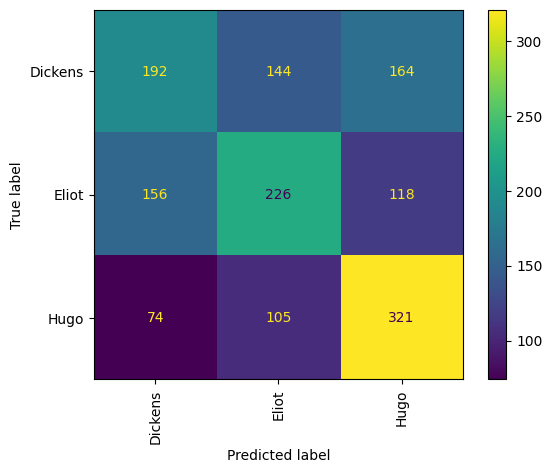

In [94]:
x_test_five_POS, y_test_five_POS, five_POS_model = utils_svm.training_val(all_documents, 5)

## Characters

#### Unigrammi di Caratteri

In [95]:
extract_documents_ngrams_normalized(all_documents, element = '',  num = 1, id_funct = 1)
sample_document.features

{'CHAR_1_W': 5.719877630081957e-08,
 'CHAR_1_h': 0.00616325394457776,
 'CHAR_1_e': 0.02155701761347658,
 'CHAR_1_n': 0.021453659424701,
 'CHAR_1_ ': 0.03686664188243689,
 'CHAR_1_M': 2.8599388150409786e-08,
 'CHAR_1_r': 0.0030771511680433416,
 'CHAR_1_.': 0.003067513174236653,
 'CHAR_1_o': 0.009202568122098109,
 'CHAR_1_p': 9.523596254086457e-06,
 'CHAR_1_s': 0.0030862457734751715,
 'CHAR_1_l': 2.828479488075528e-05,
 'CHAR_1_a': 0.009221500917053682,
 'CHAR_1_d': 0.0030863601710277733,
 'CHAR_1_i': 0.0030582755718640705,
 'CHAR_1_m': 0.006125674348548121,
 'CHAR_1_t': 0.006182186739533332,
 'CHAR_1_c': 2.814179794000323e-05,
 'CHAR_1_u': 9.40919870148482e-06,
 'CHAR_1_I': 0.0030768651741618367,
 'CHAR_1_x': 2.8599388150409786e-08,
 'CHAR_1_,': 9.43779808963523e-06,
 'CHAR_1_w': 0.012279233100542894,
 'CHAR_1_f': 1.1439755260163914e-07,
 'CHAR_1_g': 9.40919870148482e-06,
 'CHAR_1_v': 9.38059931333441e-06,
 'CHAR_1_b': 9.351999925184e-06,
 'CHAR_1_’': 9.351999925184e-06,
 'CHAR_1_k': 9.

Features pre cleaning:  3600
Numero features post filtro: 32
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.7794444444444444
Accuracy sul validation set: 0.6506666666666666
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.63      0.59      0.61       500
       Eliot       0.73      0.61      0.67       500
        Hugo       0.61      0.76      0.68       500

    accuracy                           0.65      1500
   macro avg       0.66      0.65      0.65      1500
weighted avg       0.66      0.65      0.65      1500



C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


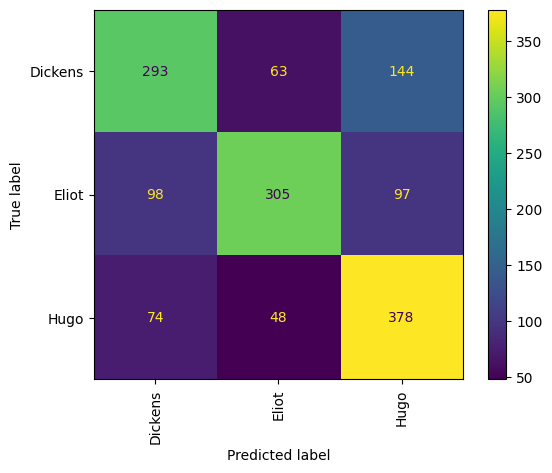

In [96]:
x_test_uni_char, y_test_uni_char, uni_char_model = utils_svm.training_val(all_documents, 5)

#### Bigrammi di Caratteri

In [97]:
extract_documents_ngrams_normalized(all_documents, element = '',  num = 2, id_funct = 1)
sample_document.features

{'CHAR_2_Wh': 2.8599388150409786e-08,
 'CHAR_2_he': 0.0030956549721766562,
 'CHAR_2_en': 0.009193130324008474,
 'CHAR_2_n ': 0.0061349691496970045,
 'CHAR_2_ M': 2.8599388150409786e-08,
 'CHAR_2_Mr': 2.8599388150409786e-08,
 'CHAR_2_r.': 2.8599388150409786e-08,
 'CHAR_2_. ': 2.8599388150409786e-08,
 'CHAR_2_ W': 2.8599388150409786e-08,
 'CHAR_2_Wo': 2.8599388150409786e-08,
 'CHAR_2_op': 5.719877630081957e-08,
 'CHAR_2_ps': 2.8599388150409786e-08,
 'CHAR_2_sl': 2.8599388150409786e-08,
 'CHAR_2_le': 9.40919870148482e-06,
 'CHAR_2_e ': 0.009230652721261811,
 'CHAR_2_ h': 0.00305821837308777,
 'CHAR_2_ha': 8.579816445122936e-08,
 'CHAR_2_ad': 5.719877630081957e-08,
 'CHAR_2_d ': 0.0030863601710277733,
 'CHAR_2_ i': 0.0030581325749233185,
 'CHAR_2_im': 5.719877630081957e-08,
 'CHAR_2_mp': 9.38059931333441e-06,
 'CHAR_2_pa': 5.719877630081957e-08,
 'CHAR_2_ar': 0.0030581611743114687,
 'CHAR_2_rt': 5.719877630081957e-08,
 'CHAR_2_te': 9.494996865936048e-06,
 'CHAR_2_ed': 9.43779808963523e-06,

Features pre cleaning:  3600
Numero features post filtro: 154
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.8466666666666667
Accuracy sul validation set: 0.6773333333333333
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.74      0.67      0.70       500
       Eliot       0.69      0.57      0.62       500
        Hugo       0.62      0.80      0.70       500

    accuracy                           0.68      1500
   macro avg       0.69      0.68      0.68      1500
weighted avg       0.69      0.68      0.68      1500



C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


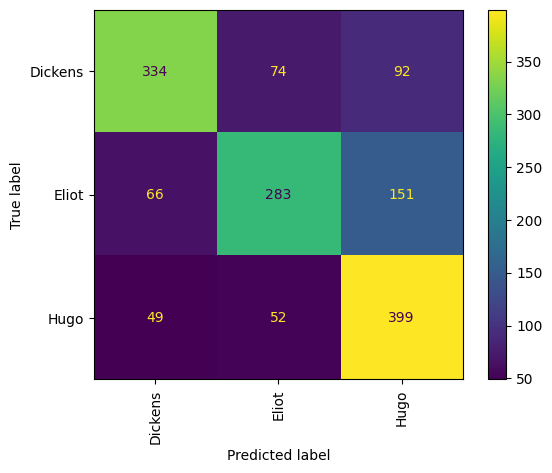

In [98]:
x_test_bi_char, y_test_bi_char, bi_char_model = utils_svm.training_val(all_documents, 5)

#### Trigrammi di Caratteri

In [99]:
extract_documents_ngrams_normalized(all_documents, element = '',  num = 3, id_funct = 1)
sample_document.features

{'CHAR_3_Whe': 2.8599388150409786e-08,
 'CHAR_3_hen': 0.003067513174236653,
 'CHAR_3_en ': 0.0030768651741618367,
 'CHAR_3_n M': 2.8599388150409786e-08,
 'CHAR_3_ Mr': 2.8599388150409786e-08,
 'CHAR_3_Mr.': 2.8599388150409786e-08,
 'CHAR_3_r. ': 2.8599388150409786e-08,
 'CHAR_3_. W': 2.8599388150409786e-08,
 'CHAR_3_ Wo': 2.8599388150409786e-08,
 'CHAR_3_Wop': 2.8599388150409786e-08,
 'CHAR_3_ops': 2.8599388150409786e-08,
 'CHAR_3_psl': 2.8599388150409786e-08,
 'CHAR_3_sle': 2.8599388150409786e-08,
 'CHAR_3_le ': 9.40919870148482e-06,
 'CHAR_3_e h': 2.8599388150409786e-08,
 'CHAR_3_ ha': 5.719877630081957e-08,
 'CHAR_3_had': 5.719877630081957e-08,
 'CHAR_3_ad ': 5.719877630081957e-08,
 'CHAR_3_d i': 2.8599388150409786e-08,
 'CHAR_3_ im': 2.8599388150409786e-08,
 'CHAR_3_imp': 2.8599388150409786e-08,
 'CHAR_3_mpa': 2.8599388150409786e-08,
 'CHAR_3_par': 5.719877630081957e-08,
 'CHAR_3_art': 5.719877630081957e-08,
 'CHAR_3_rte': 5.719877630081957e-08,
 'CHAR_3_ted': 8.579816445122936e-08

Features pre cleaning:  3600
Numero features post filtro: 258
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.8422222222222222
Accuracy sul validation set: 0.704
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.77      0.70      0.73       500
       Eliot       0.70      0.62      0.66       500
        Hugo       0.66      0.79      0.72       500

    accuracy                           0.70      1500
   macro avg       0.71      0.70      0.70      1500
weighted avg       0.71      0.70      0.70      1500



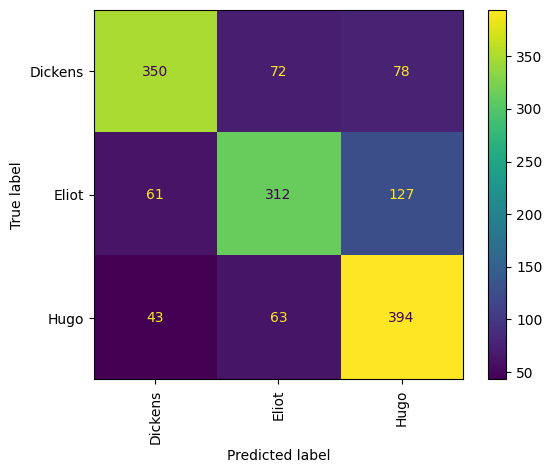

In [100]:
x_test_tri_char, y_test_tri_char, tri_char_model = utils_svm.training_val(all_documents, 5)

#### 4-ngrams di Caratteri

In [101]:
extract_documents_ngrams_normalized(all_documents, element = '',  num = 4, id_funct = 1)
sample_document.features

{'CHAR_4_When': 2.8599388150409786e-08,
 'CHAR_4_hen ': 0.003067513174236653,
 'CHAR_4_en M': 2.8599388150409786e-08,
 'CHAR_4_n Mr': 2.8599388150409786e-08,
 'CHAR_4_ Mr.': 2.8599388150409786e-08,
 'CHAR_4_Mr. ': 2.8599388150409786e-08,
 'CHAR_4_r. W': 2.8599388150409786e-08,
 'CHAR_4_. Wo': 2.8599388150409786e-08,
 'CHAR_4_ Wop': 2.8599388150409786e-08,
 'CHAR_4_Wops': 2.8599388150409786e-08,
 'CHAR_4_opsl': 2.8599388150409786e-08,
 'CHAR_4_psle': 2.8599388150409786e-08,
 'CHAR_4_sle ': 2.8599388150409786e-08,
 'CHAR_4_le h': 2.8599388150409786e-08,
 'CHAR_4_e ha': 2.8599388150409786e-08,
 'CHAR_4_ had': 5.719877630081957e-08,
 'CHAR_4_had ': 5.719877630081957e-08,
 'CHAR_4_ad i': 2.8599388150409786e-08,
 'CHAR_4_d im': 2.8599388150409786e-08,
 'CHAR_4_ imp': 2.8599388150409786e-08,
 'CHAR_4_impa': 2.8599388150409786e-08,
 'CHAR_4_mpar': 2.8599388150409786e-08,
 'CHAR_4_part': 5.719877630081957e-08,
 'CHAR_4_arte': 5.719877630081957e-08,
 'CHAR_4_rted': 5.719877630081957e-08,
 'CHAR_

Features pre cleaning:  3600
Numero features post filtro: 297
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0.8283333333333334


C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy sul validation set: 0.742
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.82      0.69      0.75       500
       Eliot       0.76      0.70      0.73       500
        Hugo       0.67      0.83      0.74       500

    accuracy                           0.74      1500
   macro avg       0.75      0.74      0.74      1500
weighted avg       0.75      0.74      0.74      1500



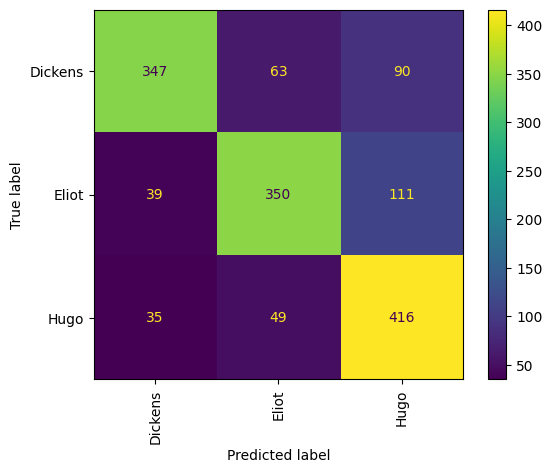

In [102]:
x_test_four_char, y_test_four_char, four_char_model = utils_svm.training_val(all_documents, 5)

#### 5-grammi di Caratteri

In [103]:
extract_documents_ngrams_normalized(all_documents, element = '',  num = 5, id_funct = 1)
sample_document.features

{'CHAR_5_When ': 2.8599388150409786e-08,
 'CHAR_5_hen M': 2.8599388150409786e-08,
 'CHAR_5_en Mr': 2.8599388150409786e-08,
 'CHAR_5_n Mr.': 2.8599388150409786e-08,
 'CHAR_5_ Mr. ': 2.8599388150409786e-08,
 'CHAR_5_Mr. W': 2.8599388150409786e-08,
 'CHAR_5_r. Wo': 2.8599388150409786e-08,
 'CHAR_5_. Wop': 2.8599388150409786e-08,
 'CHAR_5_ Wops': 2.8599388150409786e-08,
 'CHAR_5_Wopsl': 2.8599388150409786e-08,
 'CHAR_5_opsle': 2.8599388150409786e-08,
 'CHAR_5_psle ': 2.8599388150409786e-08,
 'CHAR_5_sle h': 2.8599388150409786e-08,
 'CHAR_5_le ha': 2.8599388150409786e-08,
 'CHAR_5_e had': 2.8599388150409786e-08,
 'CHAR_5_ had ': 5.719877630081957e-08,
 'CHAR_5_had i': 2.8599388150409786e-08,
 'CHAR_5_ad im': 2.8599388150409786e-08,
 'CHAR_5_d imp': 2.8599388150409786e-08,
 'CHAR_5_ impa': 2.8599388150409786e-08,
 'CHAR_5_impar': 2.8599388150409786e-08,
 'CHAR_5_mpart': 2.8599388150409786e-08,
 'CHAR_5_parte': 5.719877630081957e-08,
 'CHAR_5_arted': 5.719877630081957e-08,
 'CHAR_5_rted ': 5.

Features pre cleaning:  3600
Numero features post filtro: 299
Fitting 5 folds for each of 2 candidates, totalling 10 fits


C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


0.793611111111111


C:\Users\cinna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy sul validation set: 0.69
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.72      0.64      0.68       500
       Eliot       0.70      0.64      0.67       500
        Hugo       0.66      0.79      0.72       500

    accuracy                           0.69      1500
   macro avg       0.69      0.69      0.69      1500
weighted avg       0.69      0.69      0.69      1500



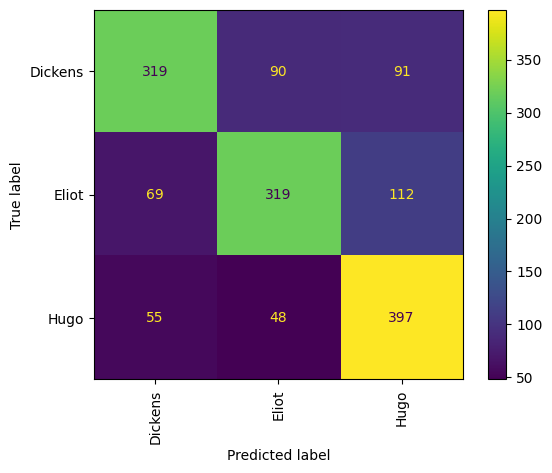

In [104]:
x_test_five_char, y_test_five_char, five_char_model = utils_svm.training_val(all_documents, 5)